In [54]:
import pandas as pd
import numpy as np
from pypfopt.expected_returns import mean_historical_return
from pypfopt.discrete_allocation import DiscreteAllocation, get_latest_prices
from collections import OrderedDict
from pandas import DataFrame
from pandas import Series
from typing import Any
from numpy.typing import NDArray
from pypfopt.risk_models import CovarianceShrinkage
from pypfopt.efficient_frontier import EfficientFrontier
import pandas as pd
from pydantic import BaseModel
from typing import TypedDict
import yfinance as yf
import json
from abc import ABC, abstractmethod
from datetime import datetime, timedelta
import time
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv()

True

Exploring stored tickers

number of current stored assets in the universe is :  22 



[*********************100%***********************]  22 of 22 completed


Ticker
BZ=F      2
CC=F      3
CL=F      3
CT=F      3
GC=F      4
HE=F      4
HG=F      3
HO=F      2
KC=F      2
LE=F      4
NG=F      2
OJ=F      2
PA=F      6
PL=F      5
RB=F      2
RIO       3
SB=F      2
SI=F      4
URA       3
ZNC=F    14
ZR=F      4
ZS=F      4
dtype: int64


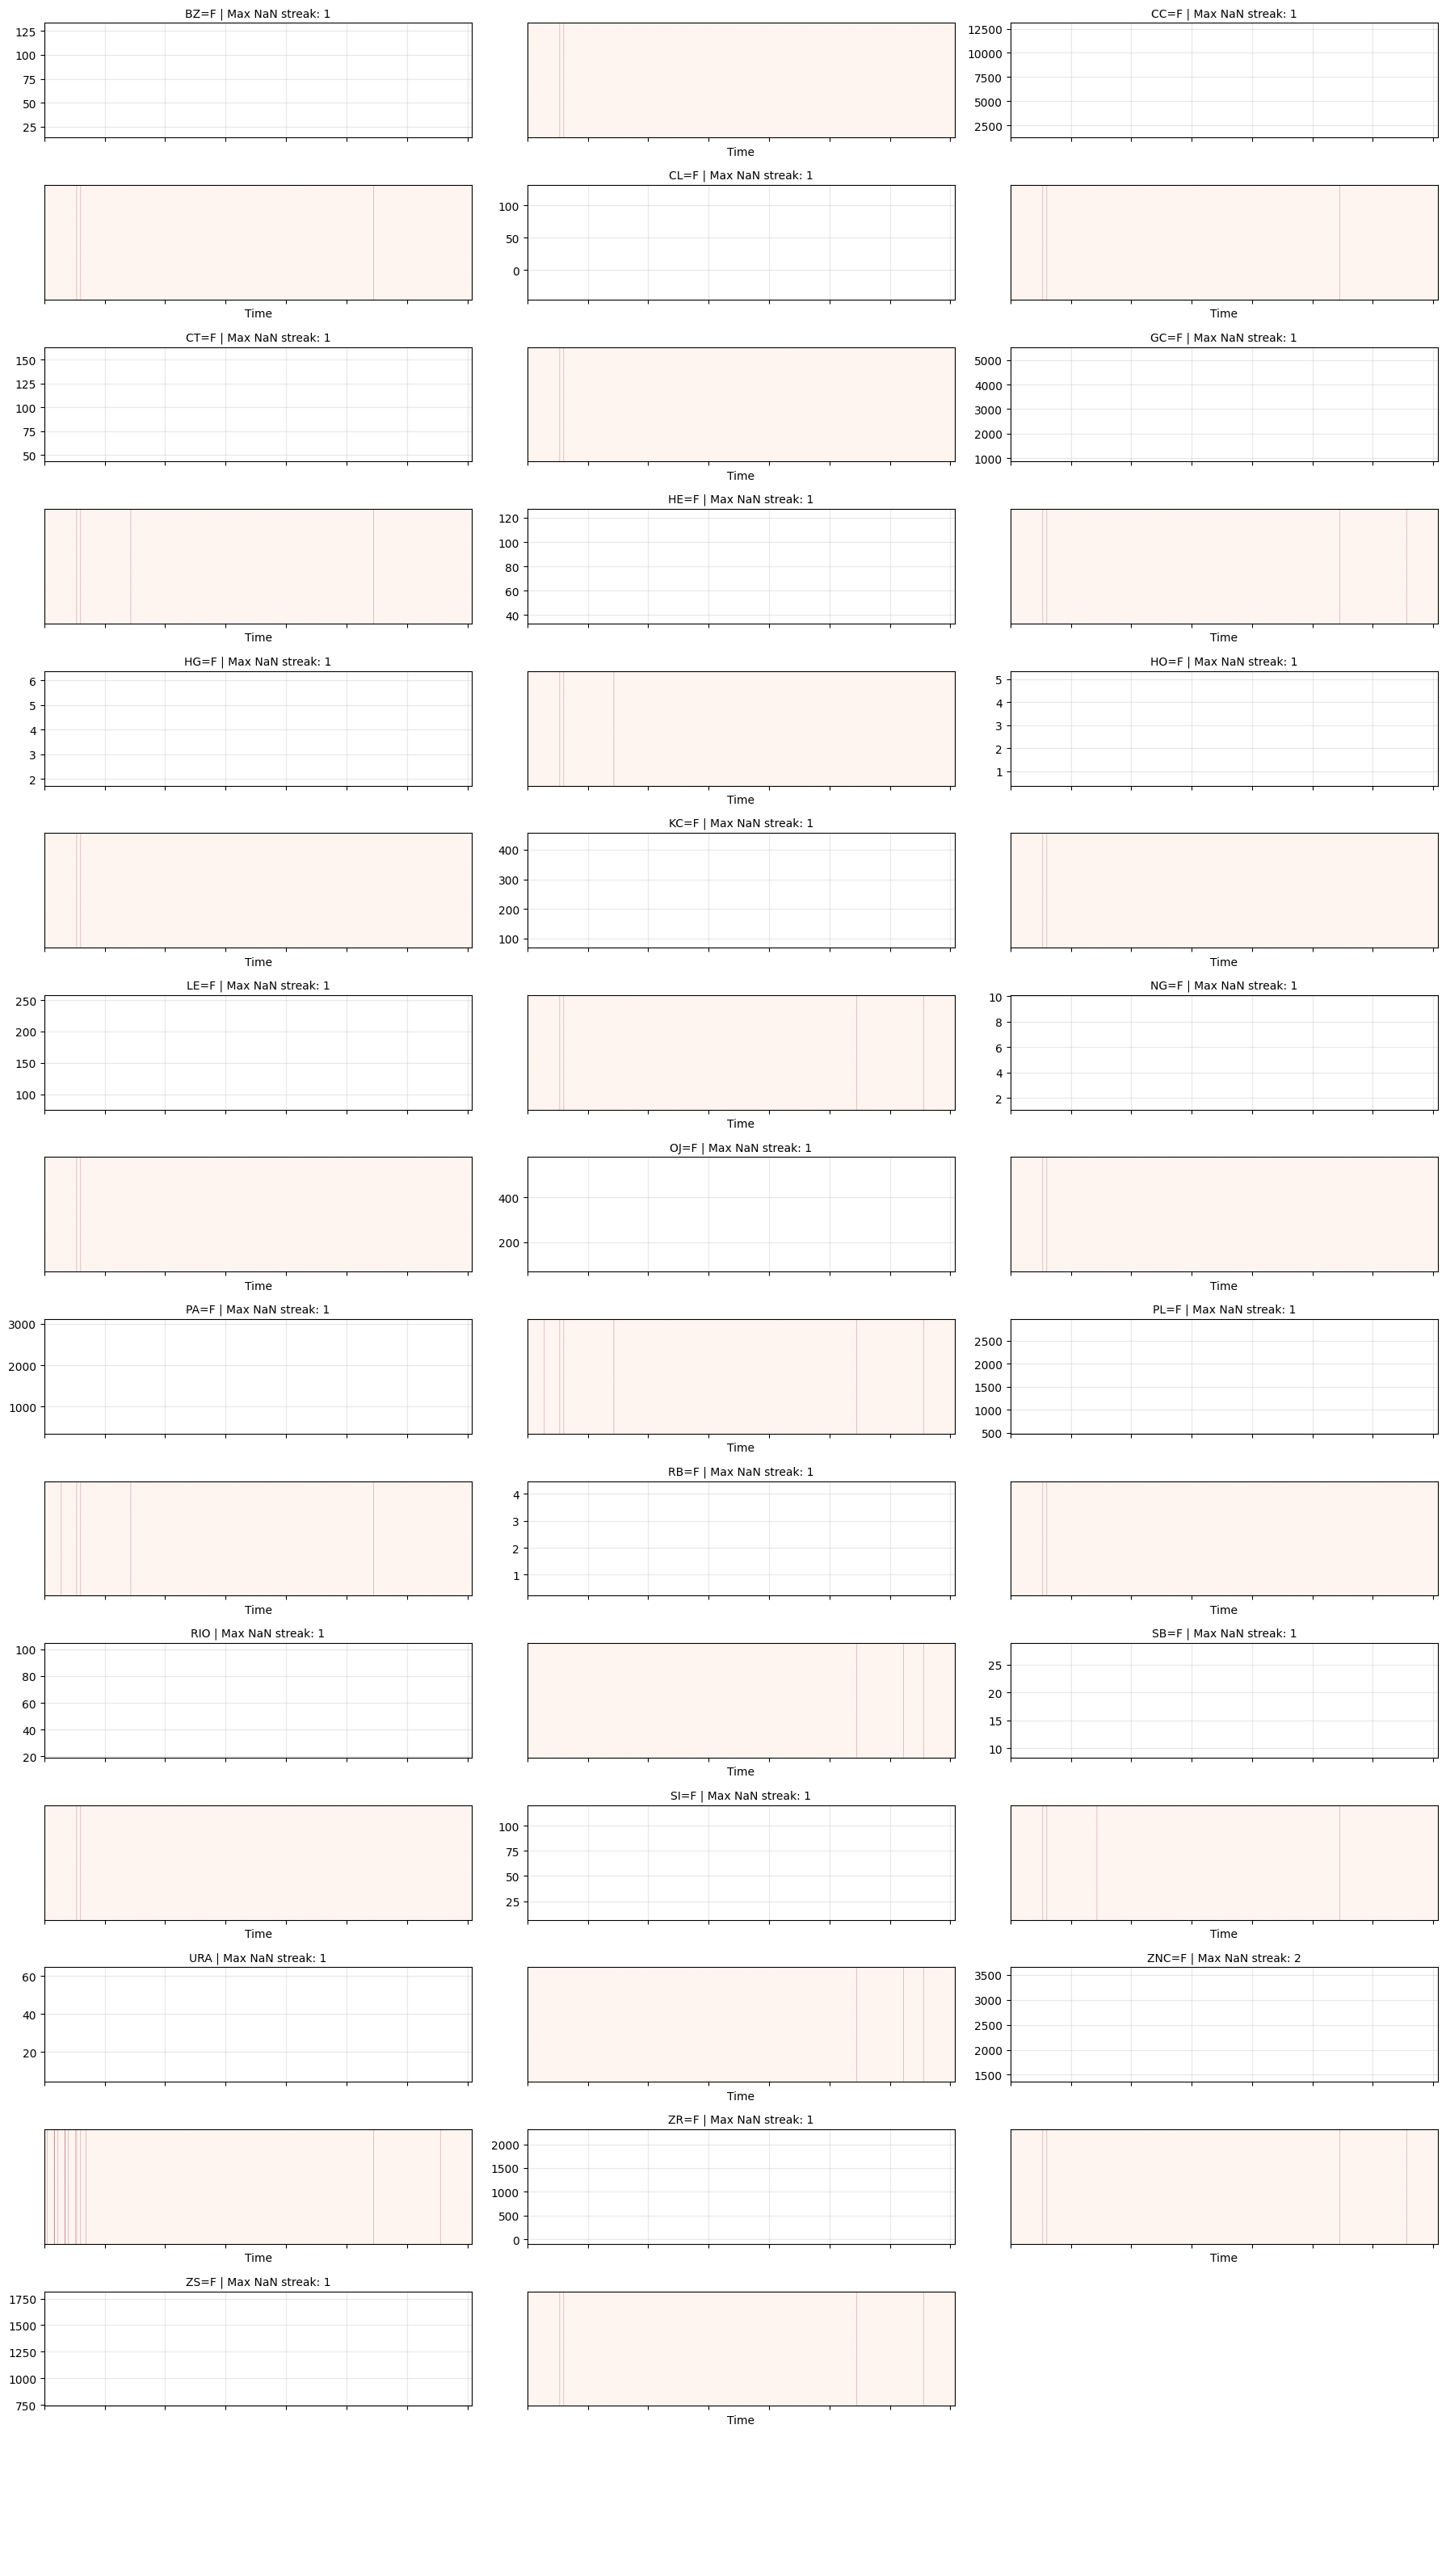

In [68]:
def clean_data(df:pd.DataFrame, nan_percentage:float,ffil_max_gap:int)->pd.DataFrame:
    """
        this function perform three cleaning phases on a dataframe:
        1- if any column has a lot of missing values, the function will drop this column entirely, if the number of missing values is acceptable, the function drops the records that contains missing data without deleting the whole column.
        2-limited filling for gaps in the data

    Args:
        df (pd.DataFrame): Two Diminsional DataFrame
        nan_percentage (float): Upper bound for the amount of  missing values
        ffil_max_gap (int): biggest number of contigeouse missing data to fill\n, for example; if the value is 10\n, the function will only fill 10 contigouse missing values\n ,it won't fill the next missing data until another sequnce of missing data appears. 

    Returns:
        pd.DataFrame: Two dimensional dataFrame that contains no missing values.
    """
    cols = [col for col in df.columns if (df[col].isna().sum()/df[col].shape[0])>nan_percentage]
    df = df.drop(cols, axis=1)
    df.ffill(limit=ffil_max_gap,inplace=True)
    df.dropna(inplace=True)
    return df

class PricesData(ABC):
    @abstractmethod
    def get_data(self):
        pass

class ApiOrMockPricesData(PricesData):
    def __init__(self,assets_tickers:list[str],start_date:str,interval:str):
        self.is_default=False
        self.assets_tickers=assets_tickers
        self.start_date=start_date
        self.interval=interval
    
    def safe_download(self,assets_tickers:list[str],start_date:str)->pd.DataFrame|None:
        try:

            end_date = (datetime.today() + timedelta(days=1)).strftime('%Y-%m-%d')
            data = yf.download(
                assets_tickers,
                start=start_date, 
                end=end_date,
                auto_adjust=False,
                threads=True,
                interval=self.interval
            )

            return data if data is not None else None

        except Exception as e:
            print(f"[ERROR] Download failed: {e}")
            return None

    def robust_download(self, max_retries=5)->pd.DataFrame|None:
        for attempt in range(max_retries):
            try:
                data:pd.DataFrame = self.safe_download(self.assets_tickers,self.start_date)#third pass of the start_date variable
                if data is not None and not data.empty:
                    return data
            except Exception as e:
                print(f"[Retry {attempt+1}] {e}")

            time.sleep(2)  # wait before retry
        print("[FAILURE] All retries failed")
        return None

    def get_data(self)->tuple[bool,pd.DataFrame]:
        data:pd.DataFrame = self.robust_download()
        if data is None:
            print("[WARNING] Using fallback data")
            self.is_default=True
            data=pd.read_parquet("historical_prices.parquet")
        return self.is_default,data
    
class MockData(PricesData):
    def __init__(self):
        self.is_default=True

    def get_data(self)->tuple[bool,pd.DataFrame]:
        return self.is_default,pd.read_parquet("historical_prices.parquet")

class HistoricalPricesService:
    """ 
        This class uses the DIP design pattern; the domain logic does not depend on hardcoded input, but depend on interface.
        In other words, this class depend on static and non-volatile entity, which is the interface in this case.
        In other words, higher level policy depends does not depend on lower level policy.
        The higher level policy-the HistoricalPricesService- uses/controls the lower level policy and does not depend on it.
        The lower level policy does depend on a higher level policy-the interface- by implmenting the abstract methods defined inside that interface. 
    """
    def __init__(self, data_source: PricesData):
        self.data_source = data_source
        
    def get_data(self)->tuple[bool,pd.DataFrame]:
        return self.data_source.get_data()

with open('country_mapper.txt', 'r') as f:
    stored_dict = json.load(f)
    stored_assets_tickers:list[str]=list(stored_dict.keys())

print("number of current stored assets in the universe is : ",len(stored_assets_tickers),"\n")

first_service=HistoricalPricesService(ApiOrMockPricesData(assets_tickers=stored_assets_tickers,start_date="2016-1-1",interval="1d" ))
is_default,prices=first_service.get_data()#this  method call never changes regardless of the underlying implmentation.
close_prices=prices["Close"]
print(close_prices.isnull().sum())


def max_nan_streak(series):
    isna = series.isna()
    groups = (isna != isna.shift()).cumsum()
    return isna.groupby(groups).sum().max()

def plot_assets_diagnostics(df, cols_per_row=3):
    n = len(df.columns)
    rows = int(np.ceil(n / cols_per_row))
    
    fig, axes = plt.subplots(rows*2, cols_per_row, figsize=(18, 4*rows), sharex=True)
    axes = axes.flatten()
    
    for i, col in enumerate(df.columns):
        price_ax = axes[2*i]
        miss_ax  = axes[2*i + 1]
        
        series = df[col]
        max_streak = max_nan_streak(series)
        
        # --- Price plot ---
        price_ax.plot(series.index, series, lw=1)
        price_ax.set_title(f"{col} | Max NaN streak: {int(max_streak)}", fontsize=10)
        price_ax.grid(alpha=0.3)
        
        # --- Missingness plot ---
        miss_ax.imshow(
            series.isna().values.reshape(1, -1),
            aspect='auto',
            cmap='Reds'
        )
        miss_ax.set_yticks([])
        miss_ax.set_xlabel("Time")
    
    # Hide empty plots
    for j in range(2*n, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run
plot_assets_diagnostics(close_prices)


In [51]:
cleaned_close_prices=clean_data(close_prices,0.05,4)
cleaned_close_prices.isnull().sum().max()

0

In [74]:
def get_asset_type(asset_name:str)->str:
    ticker = yf.Ticker(asset_name)
    info = ticker.info
    return info.get('quoteType')



def get_countries_for_tickers(ananymous_tickers:list[str],specific_info:str)->list[str]:
    result:list[str]=[]
    for ananymous_ticker in ananymous_tickers:
        result.append(yf.Ticker(ananymous_ticker).info.get(specific_info, None))
    return result

def manually_specify_tickers_details(assets_tickers:list[str])->str:
        
    dict={}
    for ticker in assets_tickers:
        if ticker in ("CL=F","BZ=F","NG=F","RB=F","HO=F","URA"):
            dict[ticker]="Energy"
        elif ticker in ("GC=F","SI=F","PL=F","PA=F"):
            dict[ticker]="Precious Metals"
        elif ticker in ("HG=F","ZNC=F","RIO"):
            dict[ticker]="Industrial Metals"
        else:
            dict[ticker]="Agricultural"
        
    return json.dumps(dict)
# Ask your self: do they really belong to what chatGPT claims ? for example : are they really commodites ?
# Ask your self : do they really belong to the United States ?



print(manually_specify_tickers_details(stored_assets_tickers))

{"CL=F": "Energy", "BZ=F": "Energy", "NG=F": "Energy", "RB=F": "Energy", "HO=F": "Energy", "GC=F": "Precious Metals", "SI=F": "Precious Metals", "PL=F": "Precious Metals", "PA=F": "Precious Metals", "HG=F": "Industrial Metals", "ZS=F": "Agricultural", "KC=F": "Agricultural", "SB=F": "Agricultural", "CC=F": "Agricultural", "CT=F": "Agricultural", "OJ=F": "Agricultural", "LE=F": "Agricultural", "HE=F": "Agricultural", "ZR=F": "Agricultural", "URA": "Energy", "RIO": "Industrial Metals", "ZNC=F": "Industrial Metals"}


In [ ]:

arr=prices["Close"].isnull().all()
tickers_to_delete:list[str]=arr[arr].index.tolist()
print("tickers_to_delete are : ",tickers_to_delete,"\n")
prices = prices.drop(columns=tickers_to_delete, level=1)
prices["Close"].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2581 entries, 2016-01-04 to 2026-04-09
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BIL     2581 non-null   float64
 1   CLTL    2322 non-null   float64
 2   FLOT    2581 non-null   float64
 3   FLRN    2581 non-null   float64
 4   GBIL    2405 non-null   float64
 5   GSY     2581 non-null   float64
 6   ICSH    2581 non-null   float64
 7   JPST    2234 non-null   float64
 8   MINT    2581 non-null   float64
 9   NEAR    2581 non-null   float64
 10  PULS    2011 non-null   float64
 11  SHV     2581 non-null   float64
 12  TFLO    2581 non-null   float64
 13  USFR    2581 non-null   float64
dtypes: float64(14)
memory usage: 302.5 KB
[]
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2581 entries, 2016-01-04 to 2026-04-09
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BIL     2581 non-null   float64
 

In [ ]:




def get_risk_appetite(questions_scores:list[int], answers_weights:list[int])-> tuple[str,int]:
    
    total_weight = sum(answers_weights)
    total_weighted_score = 0    
    for i in range(len(questions_scores)):
        total_weighted_score += questions_scores[i]*answers_weights[i]
        

    """if total_weight == 0:
        return "Unable to determine risk appetite"  # Handle edge case"""

    average_score = total_weighted_score / total_weight
    max_volatility = 1
    normalized_score = (average_score / 10) * max_volatility 
    if normalized_score <= 0.33333333: 
        risk_appetite = "Conservative"
    
    elif 0.33333334 <= normalized_score <= 0.66666666:
        risk_appetite = "Moderate"
    
    else:
        risk_appetite = "Aggressive"

    return risk_appetite,normalized_score

In [4]:
def get_risk_appetite(questions_scores:list[int], answers_weights:list[int])-> tuple[str,int]:
    

    total_weight = sum(answers_weights)
    total_weighted_score = 0    
    for i in range(len(questions_scores)):
        total_weighted_score += questions_scores[i]*answers_weights[i]
        

    """if total_weight == 0:
        return "Unable to determine risk appetite"  # Handle edge case"""

    average_score = total_weighted_score / total_weight
    max_volatility = 1
    normalized_score = (average_score / 10) * max_volatility 
    if normalized_score <= 0.33333333: 
        risk_appetite = "Conservative"
    
    elif 0.33333334 <= normalized_score <= 0.66666666:
        risk_appetite = "Moderate"
    
    else:
        risk_appetite = "Aggressive"

    return risk_appetite,normalized_score


TEST get_risk_appetite

In [ ]:
from pathlib import Path


class ReturnsAndPrices(TypedDict):
    selectedAssetsReturns:pd.DataFrame
    selectedAssetsPrices:pd.DataFrame
def select_assets(
    user_risk_prefrence:float,
    OHLC:str="Close"
    )->ReturnsAndPrices:
    """fetch real-time assets prices data, cleans it from missing values, and picks assets that with acceptable risk .

    Args:
        user_risk_prefrence (float): upperbound of preferred risk; measure of the willingness to hold volatile assets
        OHLC (str, optional): to get prices of assets in differnt time line of the market; when the market "Open", "High", "Low", or "Close". Defaults to "close".. Defaults to "close".
    Returns:
        pd.DataFrame:  The returns(in decimal) for each selected asset over time. negative return values incidcates a drop in the asset price relative to the last observed price.  
    """
    #guard against non-logical risk prefrence using clipping; max controls lower bound, min control upper bound
    user_risk_prefrence = max(0, min(1, user_risk_prefrence))
    
    BASE_DIR = Path(__file__).resolve().parent
    file_path = BASE_DIR / "country_mapper.txt"
    with open(file_path, 'r') as f:
        assets_countries = json.load(f)

    first_service=HistoricalPricesService(ApiOrMockPricesData(assets_tickers=list(assets_countries.keys())))
    is_default,prices=first_service.get_data()#this  method call never changes regardless of the underlying implementation ; DIP design pattern.
    print(f"THE DEFAULT REAL-TIME PRICES WAS USED ? :  {is_default}")
    cleaned_prices=clean_data(prices[OHLC],0.50 ,3)
    returns = cleaned_prices.pct_change() 
    print('\nreturns shape is : ',returns.shape,'\n') #nothing wrong here, after this line, something is modifying this data?

    covarience_matrix :pd.DataFrame | NDArray[Any] | Any= CovarianceShrinkage(returns, returns_data=True).ledoit_wolf() 
    assets_volatilities:NDArray[Any] = np.sqrt(np.diag(covarience_matrix))
    
    #ONLY THING I DICUSS WITH CHATGPT: THE FOLLOWING CODE IS CAUSING CHANGING IN THE SHAPE OF THE RETURNS, POSIBLY DELETING ALL THE COLUMNS
    print("\nuser_risk_preference is:",user_risk_prefrence,"\n")
    selected_assets_indicies=[index for index  in range(len(list(cleaned_prices.columns) )) if  assets_volatilities[index]<= user_risk_prefrence]
    selected_assets_names=[list(cleaned_prices.columns)[i] for i in selected_assets_indicies]
    print("\nselected assets names are: ",selected_assets_names,"\n") # chatGPT should notice that the output of this print statement is empty list.
    
    return ReturnsAndPrices(
            selectedAssetsReturns=returns[selected_assets_names],
            selectedAssetsPrices=cleaned_prices[selected_assets_names]
            )    

testing select_assets

In [7]:

tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'LLY', 'V',
    'JPM', 'UNH', 'MA', 'PG', 'HD', 'JNJ', 'MRK', 'ABBV', 'COST', 'CVX',
    'BAC', 'KO', 'PEP', 'AVGO', 'WMT', 'ORCL', 'TMO', 'CSCO', 'ADBE', 'NFLX',
    'CRM', 'CMCSA', 'PFE', 'TMUS', 'ABT', 'DIS', 'XOM', 'WFC', 'INTC', 'NKE',
    'AMD', 'PM', 'COP', 'UPS', 'CAT', 'MS', 'BA', 'GE', 'GS', 'SPY','DBI','DIB.AE'
]

returns_and_prices=select_assets(tickers, "2017-3-10", 0.3)

[*********************100%***********************]  52 of 52 completed


In [9]:
list(returns_and_prices.keys())


['selectedAssetsReturns', 'selectedAssetsPrices']

In [10]:


class EfficientFrontierPointStaticType(TypedDict): # static type hint; not for run time validaton
          volatility: float
          expectedReturn: float


def compute_frontier(ef, points=50)->list[EfficientFrontierPointStaticType]:
    """determine the volatality and expected return for each efficient portfolio

    Args:
        ef (_type_): _description_
        points (int, optional): _description_. Defaults to 50.

    Returns:
        list[EfficientFrontierPointStaticType]: _description_
    """
    import numpy as np

    ef_min = ef.deepcopy()
    ef_max = ef.deepcopy()

    ef_min.min_volatility()
    min_ret = ef_min.portfolio_performance()[0]

    max_ret = ef_max._max_return()

    ef_range = np.linspace(min_ret, max_ret - 1e-4, points)

    frontier = []

    for target in ef_range:
        ef_copy = ef.deepcopy()
        try:
            ef_copy.efficient_return(target)
            ret, vol, _ = ef_copy.portfolio_performance()

            frontier.append({
                "volatility": float(vol),
                "expectedReturn": float(ret)
            })

        except Exception:
            continue

    
    frontier.sort(key=lambda x: x["volatility"])

    return frontier

Testing compute_frontier


In [37]:
returns=returns_and_prices["selectedAssetsReturns"]
covarience_matrix :DataFrame | NDArray[Any] | Any= CovarianceShrinkage(returns,returns_data=True).ledoit_wolf()                    
volatilities:NDArray[Any] = np.sqrt(np.diag(covarience_matrix))      
#smoothed_bealived_estimated_yearly_returns = realized_evidence_daily_returns.ewm(alpha=0.7).mean().iloc[-1]*252 

annualized_mean_returns :  (Series | Any)= mean_historical_return(returns,returns_data=True) # Note 3 : use Series[Any] for mypy, python does not accept it .
ef = EfficientFrontier(annualized_mean_returns, covarience_matrix,verbose=False,solver='CLARABEL')#['CLARABEL', 'HIGHS', 'OSQP', 'SCIP', 'SCIPY', 'SCS']
ef_copy:EfficientFrontier=ef.deepcopy() # rule : when making copy of the ef, it must always be before modifying the ef
ef.max_sharpe()

sharp_risk=ef.portfolio_performance()[1]



""" 
#Uncomment this later
efficientFrontierPoints=compute_frontier(ef) 
pprint(efficientFrontierPoints,sort_dicts=False)#PROBLEM: STORE THIS VALUE IN THE DATABASE.FRONTEND ALSO NEED THIS VALUE. """

float(np.max(volatilities))

ef_copy.min_volatility()#internal allocations optimized to give lowest amount of risk
min_risk:float = ef_copy.portfolio_performance()[1]

print(sharp_risk,'\n\n',min_risk)


0.1519168005820395 

 0.11763733618477892


In [ ]:
def get_allocations_percentages(risk_appetite:str,risk_score:float,ef:EfficientFrontier,volatilities:NDArray[Any] )->OrderedDict[int,float]:
        

    if risk_appetite=="Conservative":
        capital_allocations_percentages:OrderedDict[int, float]=ef.min_volatility()
        print("optimized for lowest risk")     
    
    elif risk_appetite=="Moderate":
        capital_allocations_percentages:OrderedDict[int,float] = ef.max_sharpe()
        print("optimzed for maximum sharp ratio")
    else:#aggressive 
        ef_copy:EfficientFrontier = ef.deepcopy()
        ef_copy.min_volatility()
        min_risk:float = ef_copy.portfolio_performance()[1]
        
        max_risk = float(np.max(volatilities))
        capital_allocations_percentages:OrderedDict[int,float] = ef.efficient_risk(target_volatility=max(min_risk, min(risk_score,max_risk)))
        print("optimized for maximum return given target risk (aggressive)")
    return capital_allocations_percentages 

In [40]:
class AssetScatterPointStaticType(TypedDict):
      ticker: str
      volatility: float
      expectedReturn:float

class PerformenceMetricsStaticType(TypedDict):
        expectedAnnualReturn: float
        annualVolatility: float   
        sharpeRatio: float
        
class AssetsAllocationsResults(TypedDict):
    leftover:float
    sharesQuantities:dict[str,int]
    riskReturnScatterPoints:list[AssetScatterPointStaticType]
    efficientFrontierPoints:list[EfficientFrontierPointStaticType]
    capitalAllocationsPercentages:dict[str,float]
    performanceMetrics:PerformenceMetricsStaticType

def perform_assets_allocation(
          selected_assets_returns:pd.DataFrame, 
          selected_assets_prices:pd.DataFrame, 
          total_portfolio_value:float,
          risk_appetitie:str,
          risk_score:float=0.20
          )->AssetsAllocationsResults:
      
    covarience_matrix :DataFrame | NDArray[Any] | Any= CovarianceShrinkage(selected_assets_returns,returns_data=True).ledoit_wolf()       
    volatilities:NDArray[Any] = np.sqrt(np.diag(covarience_matrix))                                  
    annualized_mean_returns :  (Series | Any)= mean_historical_return(selected_assets_returns,returns_data=True) # Note 3 : use Series[Any] for mypy, python does not accept it .
    tickers:list[str] = list(annualized_mean_returns.index)
    # PROBLEM: must be returned to frontend and stored in the database
    risk_return_scatter_points = [
        {
            "ticker": ticker,
            "volatility": float(vol),
            "expectedReturn": float(expec_ret)
        }
        for ticker, vol, expec_ret in zip(tickers, volatilities, annualized_mean_returns.values)
    ] 
    ef = EfficientFrontier(annualized_mean_returns, covarience_matrix,verbose=False,solver='CLARABEL')#['CLARABEL', 'HIGHS', 'OSQP', 'SCIP', 'SCIPY', 'SCS']
    
    efficient_frontier_points=compute_frontier(ef)                                        #PROBLEM: STORE THIS VALUE IN THE DATABASE.
    #comment: search through the portfolios and pick the one with the highest risk-adjusted return (Sharp ratio)
    

    
    capital_allocations_percentages:OrderedDict[int,float]=get_allocations_percentages(risk_appetite=risk_appetitie,risk_score=risk_score, ef=ef,volatilities=volatilities)
    
    
    # drop assets that have no allocation .
    capital_allocations_percentages={
        asset_name:capital_allocation_percentage
        for asset_name, capital_allocation_percentage in capital_allocations_percentages.items() if capital_allocations_percentages[asset_name]>0
    }
    
    

    
    cleaned_assets_allocations:OrderedDict[int ,float]=ef.clean_weights()  

    performence_metrics=ef.portfolio_performance(verbose=False)                                          # metrics must be calculated after optimization
    performence_metrics=tuple(map(float, performence_metrics))
    parsed_metrics={
        "expectedAnnualReturn": performence_metrics[0],
        "annualVolatility": performence_metrics[1],   
        "sharpeRatio": performence_metrics[2]
        }
    latest_prices = get_latest_prices(selected_assets_prices)                                  # Problem : Print the value of this 
    #print(df1.iloc[-1]==latest_prices)
    #print(latest_prices.sort_values())
    
    da = DiscreteAllocation(cleaned_assets_allocations, latest_prices, total_portfolio_value=total_portfolio_value)
    shares_quantities, leftover = da.lp_portfolio(verbose=False) # Problem :  reinvest is related to the rebalancing
    
    #ensure no mismatch between the keys of shares_quantites and capital_allocations_percentages
    #the mismtach between the keys is during the fact the capital_allocations_percentages contains very small allocations that are near zero, so they are not encluded in the qunatities
    #PROBLEM: some allocations are lost, those allocations must be added to the leftover for accruacy, so that the user does not get confused on where his money gone !
    capital_allocations_percentages={k:v for k,v in capital_allocations_percentages.items() if k in list(shares_quantities.keys()) }
    
    leftover=float(leftover)    
    return AssetsAllocationsResults(
          leftover=leftover,
          sharesQuantities=shares_quantities,
          riskReturnScatterPoints=risk_return_scatter_points,
          efficientFrontierPoints=efficient_frontier_points,
          capitalAllocationsPercentages=capital_allocations_percentages,
          performanceMetrics=parsed_metrics
        ) 

TESTING perform_asset_allocation

In [41]:

total_portfolio_value=2000000 

prices=returns_and_prices["selectedAssetsPrices"]

result:AssetsAllocationsResults=perform_assets_allocation(returns,prices ,total_portfolio_value,risk_appetitie="Conservative",risk_score=0.2)



TESTING

In [42]:
list(result.keys())

['leftover',
 'sharesQuantities',
 'riskReturnScatterPoints',
 'efficientFrontierPoints',
 'capitalAllocationsPercentages',
 'performanceMetrics']

In [ ]:

class Asset(BaseModel):
    assetName: str
    capitalAllocationPercentage: float
    quantity: int
          
class Metrics(BaseModel): 

    expectedAnnualReturn: float
    annualVolatility: float
    sharpeRatio: float

class OptimalPortfolio(BaseModel): 

    assets:list[Asset] 
    metrics:Metrics 
      
class AssetScatterPoint(BaseModel):
    ticker: str
    volatility: float
    expectedReturn:float
      
class EfficientFrontierPoint(BaseModel): 
    volatility: float
    expectedReturn: float

class  InvestementsAdviceMocks (BaseModel) :
      leftover: float
      optimalPortfolio:OptimalPortfolio 
      assetsScatter: list[AssetScatterPoint]
      efficientFrontierPoints: list[EfficientFrontierPoint]
def investements_advice_orchestrator(
        question_scores:list[int],
        answers_weights:list[int], 
        total_portfolio_value:float, 
        assets_names:list[str],
        start_date:str="2024-3-27"
       
    )->InvestementsAdviceMocks:


    risk_appetite,normalized_risk_score=get_risk_appetite(questions_scores=question_scores,answers_weights=answers_weights)

        
    returns_and_prices: ReturnsAndPrices=select_assets(assets_names,start_date,normalized_risk_score,auto_adjust=True)

    

    intermediate_results:AssetsAllocationsResults=perform_assets_allocation(returns_and_prices["selectedAssetsReturns"], returns_and_prices["selectedAssetsPrices"],total_portfolio_value,risk_appetitie=risk_appetite,risk_score=normalized_risk_score)
    
    
    selected_assets_names=list(intermediate_results["capitalAllocationsPercentages"].keys())
    
    
    leftover=intermediate_results["leftover"]

    optimalPortfolio:OptimalPortfolio={
     
        "assets":[
            {
                "assetName":asset_name,
                "capitalAllocationPercentage":intermediate_results["capitalAllocationsPercentages"][asset_name],
                "quantity":intermediate_results["sharesQuantities"][asset_name]
            }
            for asset_name in selected_assets_names
        ] ,
        
        
        "metrics":intermediate_results["performanceMetrics"]
    }
    assetsScatter:list[AssetScatterPoint]=intermediate_results["riskReturnScatterPoints"]


    efficientFrontierPoints: list[EfficientFrontierPoint]=intermediate_results["efficientFrontierPoints"]
    
    return InvestementsAdviceMocks(
            leftover=leftover,
            optimalPortfolio=optimalPortfolio,
            assetsScatter=assetsScatter,
            efficientFrontierPoints=efficientFrontierPoints,
             )



In [ ]:
total_portfolio_value=20000.0           #PROBLEM : total_investement_amount # Fetch from user_portfolio_state table 
question_scores=[1,4,6,8,8,6,6,1,1,4]   #PROBLEM:  provided by frontend (simulated for now)
answers_weights=[1,10,3,3,6,1,5,7,6,2]  #PROBLEM : provided by frontend(simulated for now )
tickers=['AAPL', 'ABBV', 'ABT', 'ADA-USD', 'ADBE', 'AMD', 'AMZN', 'AVGO', 'BA', 'BAC', 'BCH-USD', 'BNB-USD', 'BRK-B', 'BTC-USD', 'CAT', 'CMCSA', 'COP', 'COST', 'CRM', 'CSCO', 'CVX', 'DIB.AE', 'DIS', 'DOGE-USD', 'ETH-USD', 'GE', 'GOOGL', 'GS', 'HD', 'HYG', 'INTC', 'IWM', 'JNJ', 'JPM', 'KO', 'LINK-USD', 'LLY', 'LQD', 'MA', 'META', 'MRK', 'MS', 'MSFT', 'NFLX', 'NKE', 'NVDA', 'ORCL', 'PEP', 'PFE', 'PG', 'PM', 'QQQ', 'SLV', 'SOXL', 'SOXS', 'SPY', 'SQQQ', 'TLT', 'TMO', 'TMUS', 'TQQQ', 'TSLA', 'TZA', 'UNH', 'UPS', 'USDT-USD', 'V', 'WETH-USD', 'WFC', 'WMT', 'XLE', 'XLF', 'XOM', 'XRP-USD']

advice:InvestementsAdviceMocks=investements_advice_orchestrator(question_scores,answers_weights, total_portfolio_value,tickers )


[*********************100%***********************]  74 of 74 completed


In [120]:
#advcie contains the following things 'leftover', 'optimalPortfolio', 'assetsScatter', 'efficientFrontierPoints'
advice.assetsScatter


[AssetScatterPoint(ticker='AAPL', volatility=0.234101187226484, expectedReturn=0.13966703106762068),
 AssetScatterPoint(ticker='ABBV', volatility=0.22020853936984042, expectedReturn=0.08408633016163503),
 AssetScatterPoint(ticker='ABT', volatility=0.18389234656920117, expectedReturn=-0.014303279919215206),
 AssetScatterPoint(ticker='ADBE', volatility=0.2743276546268326, expectedReturn=-0.23634622593314647),
 AssetScatterPoint(ticker='AMZN', volatility=0.26274446446730865, expectedReturn=0.03865250942512399),
 AssetScatterPoint(ticker='BA', volatility=0.29171235464918505, expectedReturn=-0.003945578441739039),
 AssetScatterPoint(ticker='BAC', volatility=0.21412081150858314, expectedReturn=0.09809043063450451),
 AssetScatterPoint(ticker='BRK-B', volatility=0.15433804122716074, expectedReturn=0.04391345659674939),
 AssetScatterPoint(ticker='BTC-USD', volatility=0.39038289207081517, expectedReturn=-0.02016304949308545),
 AssetScatterPoint(ticker='CAT', volatility=0.25781066066219255, expec

REBALANCING SERVICE TESTING

In [5]:
class TradeOrder(BaseModel):
       
        assetName: str
        action: str
        numOfShares: int
          
class RebalancingData(BaseModel):
        
    tradeOrders: list [TradeOrder]
    rebalancingNeedDetectedAt: str 